In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [2]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [3]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [4]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [5]:
# drop 2024 data for date of discovery and initial report date
spills_gdf = spills_gdf[spills_gdf['Date of Discovery'].dt.year < 2024]
spills_gdf = spills_gdf[spills_gdf['Initial Report Date'].dt.year < 2024]



In [6]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [7]:
# Compare Reporting Delay
report_delay_summary = spills_gdf.groupby('Spill Type')['Report Delay (Days)'].describe()
print(report_delay_summary)

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the report delay summary to a markdown file
with open(os.path.join(output_dir, 'report_delay_summary.md'), 'w') as f:
    f.write("# Report Delay Summary\n\n")
    f.write(report_delay_summary.to_markdown())


              count       mean         std  min  25%  50%  75%     max
Spill Type                                                            
Historical   5312.0  21.490023  205.615913  0.0  0.0  1.0  2.0  9261.0
Recent      10678.0   3.964506   46.997749  0.0  0.0  1.0  2.0  2232.0


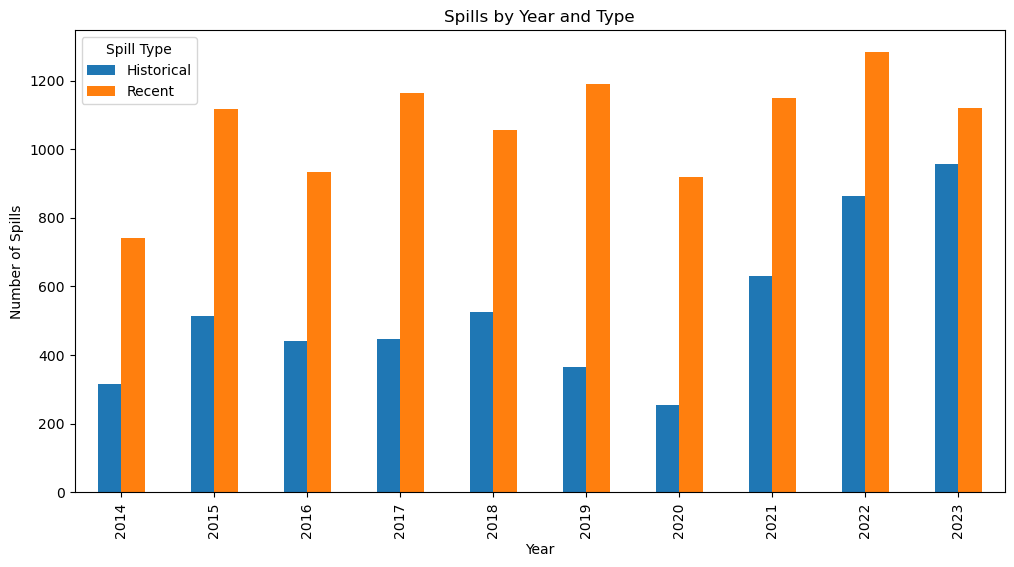

In [8]:
import matplotlib.pyplot as plt

# Compare Spill Trends Over Time
spills_by_year = spills_gdf.groupby(['Report Year', 'Spill Type']).size().unstack()
ax = spills_by_year.plot(kind='bar', figsize=(12,6), title='Spills by Year and Type')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Spills')
ax.legend(title='Spill Type')

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the plot
plt.savefig(f'{output_dir}/spills_by_year_and_type.png')

# Display the plot
plt.show()

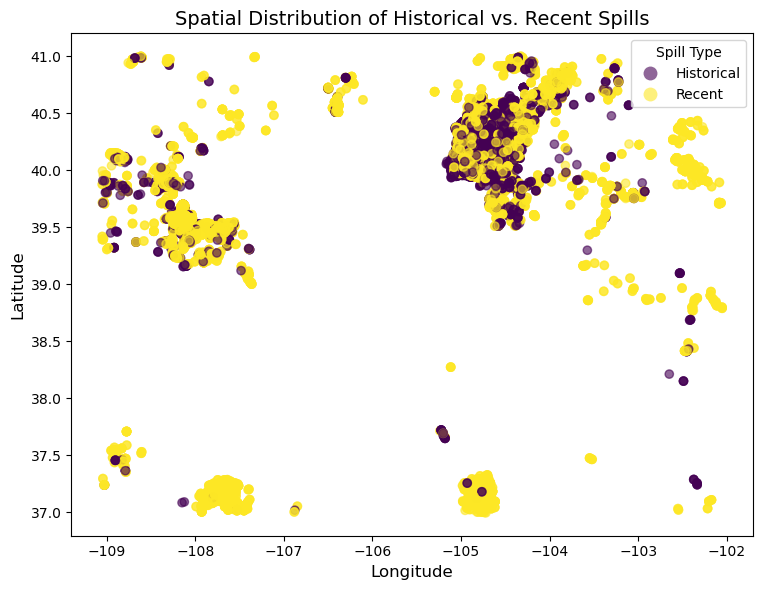

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure spills_gdf is already a GeoDataFrame with the necessary data
# spills_gdf = gpd.GeoDataFrame(...)

# Create a plot for the spatial distribution of spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations
spills_gdf.plot(
    ax=ax,
    marker='o', 
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type', 
    legend=True, 
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


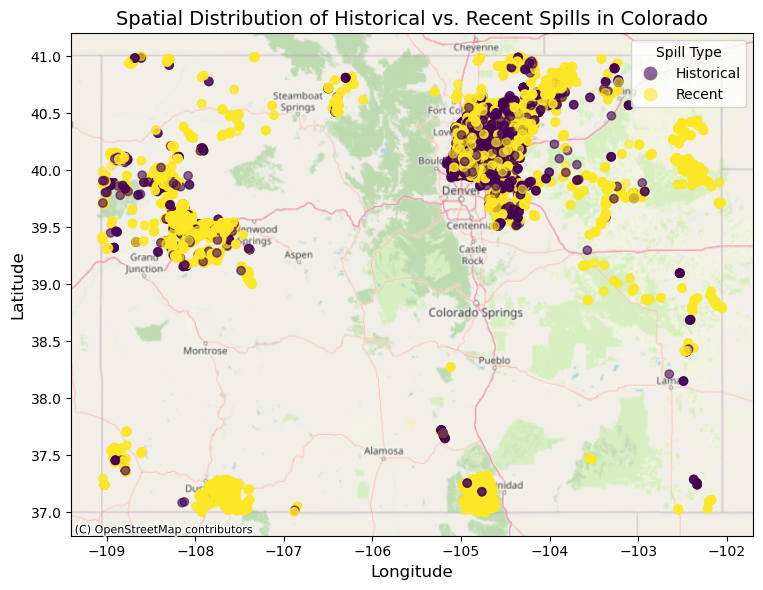

In [10]:
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np

# Use your ORIGINAL plot code exactly as it is, just adding the basemap at the end
# This ensures all your data points, colors and categories remain intact

# Starting with your original code:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations - YOUR ORIGINAL PLOTTING CODE
spills_gdf.plot(
    ax=ax,
    marker='o',
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type',
    legend=True,
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills in Colorado', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Store the current axis limits to restore them after adding basemap
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Before adding the basemap, convert the axes coordinates to Web Mercator
# This is a crucial step that lets us keep your original points exactly as they are
from pyproj import Transformer

# Create transformer from lat/lon to Web Mercator
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transform the limits
west, south = transformer.transform(xlim[0], ylim[0])
east, north = transformer.transform(xlim[1], ylim[1])

# Add the basemap - this will be UNDER your existing points
ctx.add_basemap(
    ax,
    crs=spills_gdf.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom="auto"
)

# Restore original axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Improve layout
plt.tight_layout()

# Save the plot to the analysis/output directory
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f'{output_dir}/spatial_distribution_spills.png')

# Show the plot
plt.show()

In [11]:
# Add a column to indicate whether the spill occurred before or after 2020
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')

# Group by the new period column and calculate the mean response time
response_time_summary = spills_gdf.groupby('Period')['Report Delay (Days)'].describe()
print(response_time_summary)

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the response time summary to a markdown file
with open(os.path.join(output_dir, 'response_time_summary.md'), 'w') as f:
    f.write("# Response Time Summary\n\n")
    f.write(response_time_summary.to_markdown())

                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2020 and After  7177.0   6.924342  124.965839  0.0  0.0  1.0  1.0  9261.0
Before 2020     8813.0  12.117554  124.705876  0.0  0.0  1.0  2.0  5681.0


T-Statistic: 2.6161
P-Value: 0.0089
The difference in response time is statistically significant.


<Axes: title={'center': 'Report Delay (Days)'}, xlabel='Period'>

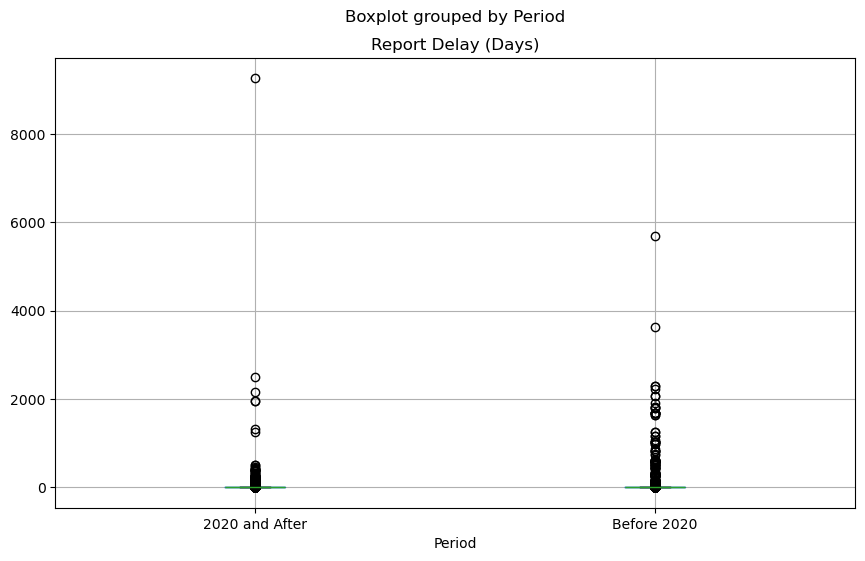

In [12]:
# t-test for the difference in response time before and after 2020
from scipy.stats import ttest_ind

before_2020 = spills_gdf[spills_gdf['Period'] == 'Before 2020']['Report Delay (Days)']
after_2020 = spills_gdf[spills_gdf['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(before_2020, after_2020, equal_var=False)
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

# Check if the difference is statistically significant
if p_value < 0.05:
    print('The difference in response time is statistically significant.')
else:
    print('The difference in response time is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2020
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for each period
spills_gdf.boxplot(column='Report Delay (Days)', by='Period', ax=ax)




In [13]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [14]:
import tabulate
from scipy.stats import ttest_ind

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Add a column to indicate whether the spill occurred before or after 2020 for historical and recent spills
historical_spills['Period'] = historical_spills['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')
recent_spills['Period'] = recent_spills['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')

# Historical Spills Analysis
historical_report_delay_summary = historical_spills['Report Delay (Days)'].describe()
print("Historical Spills Report Delay Summary:")
print(historical_report_delay_summary)

# Recent Spills Analysis
recent_report_delay_summary = recent_spills['Report Delay (Days)'].describe()
print("\nRecent Spills Report Delay Summary:")
print(recent_report_delay_summary)

# Historical Spills Response Time Summary
historical_response_time_summary = historical_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nHistorical Spills Response Time Summary:")
print(historical_response_time_summary)

# Recent Spills Response Time Summary
recent_response_time_summary = recent_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nRecent Spills Response Time Summary:")
print(recent_response_time_summary)

# t-test for the difference in response time before and after 2020 for historical spills
historical_before_2020 = historical_spills[historical_spills['Period'] == 'Before 2020']['Report Delay (Days)']
historical_after_2020 = historical_spills[historical_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat_historical, p_value_historical = ttest_ind(historical_before_2020, historical_after_2020, equal_var=False)
print(f'\nHistorical Spills T-Statistic: {t_stat_historical:.4f}')
print(f'Historical Spills P-Value: {p_value_historical:.4f}')

# Check if the difference is statistically significant for historical spills
if p_value_historical < 0.05:
    print('The difference in response time for historical spills is statistically significant.')
else:
    print('The difference in response time for historical spills is not statistically significant.')
    
# t-test for the difference in response time before and after 2020 for recent spills
recent_before_2020 = recent_spills[recent_spills['Period'] == 'Before 2020']['Report Delay (Days)']
recent_after_2020 = recent_spills[recent_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat_recent, p_value_recent = ttest_ind(recent_before_2020, recent_after_2020, equal_var=False)
print(f'\nRecent Spills T-Statistic: {t_stat_recent:.4f}')
print(f'Recent Spills P-Value: {p_value_recent:.4f}')

# Check if the difference is statistically significant for recent spills
if p_value_recent < 0.05:
    print('The difference in response time for recent spills is statistically significant.')
else:
    print('The difference in response time for recent spills is not statistically significant.')

# Save the summaries and t-test results to a markdown file
with open(os.path.join(output_dir, 'analysis_results.md'), 'w') as f:
    f.write("# Analysis Results\n\n")
    
    f.write("## Historical Spills Report Delay Summary:\n")
    f.write(historical_report_delay_summary.to_markdown() + "\n\n")
    
    f.write("## Recent Spills Report Delay Summary:\n")
    f.write(recent_report_delay_summary.to_markdown() + "\n\n")
    
    f.write("## Historical Spills Response Time Summary:\n")
    f.write(historical_response_time_summary.to_markdown() + "\n\n")
    
    f.write("## Recent Spills Response Time Summary:\n")
    f.write(recent_response_time_summary.to_markdown() + "\n\n")
    
    f.write("## T-Test Results for Historical Spills\n")
    f.write(f"T-Statistic: {t_stat_historical:.4f}\n")
    f.write(f"P-Value: {p_value_historical:.4f}\n")
    if p_value_historical < 0.05:
        f.write('The difference in response time for historical spills is statistically significant.\n')
    else:
        f.write('The difference in response time for historical spills is not statistically significant.\n')
    
    f.write("\n## T-Test Results for Recent Spills\n")
    f.write(f"T-Statistic: {t_stat_recent:.4f}\n")
    f.write(f"P-Value: {p_value_recent:.4f}\n")
    if p_value_recent < 0.05:
        f.write('The difference in response time for recent spills is statistically significant.\n')
    else:
        f.write('The difference in response time for recent spills is not statistically significant.\n')

Historical Spills Report Delay Summary:
count    5312.000000
mean       21.490023
std       205.615913
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      9261.000000
Name: Report Delay (Days), dtype: float64

Recent Spills Report Delay Summary:
count    10678.000000
mean         3.964506
std         46.997749
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       2232.000000
Name: Report Delay (Days), dtype: float64

Historical Spills Response Time Summary:
                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2020 and After  2705.0  13.533087  200.352339  0.0  0.0  0.0  1.0  9261.0
Before 2020     2607.0  29.746068  210.659491  0.0  0.0  1.0  2.0  5681.0

Recent Spills Response Time Summary:
                 count      mean        std  min  25%  50%  75%     max
Period                                         

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


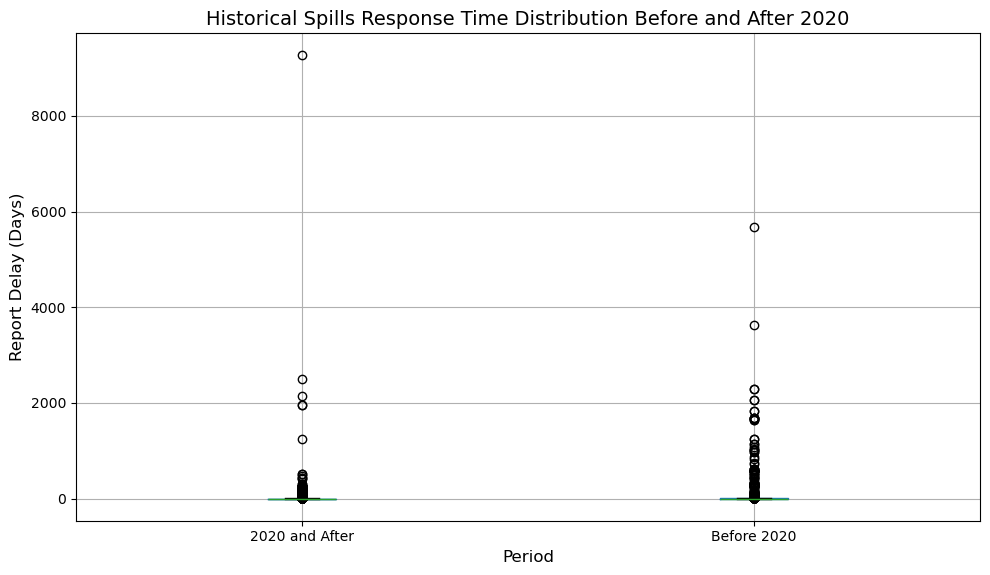

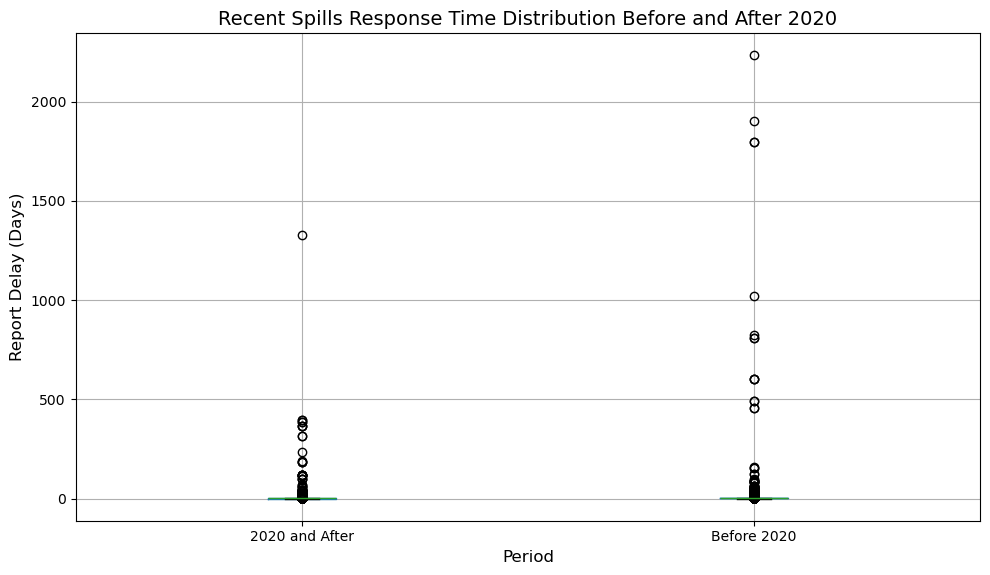

In [15]:
import os

# Ensure the output directory exists
output_dir = 'analysis/output'
os.makedirs(output_dir, exist_ok=True)

# Save the t-test results to a markdown file
with open(os.path.join(output_dir, 't_test_results.md'), 'w') as f:
    f.write(f"## T-Test Results for Historical Spills\n")
    f.write(f"T-Statistic: {t_stat_historical:.4f}\n")
    f.write(f"P-Value: {p_value_historical:.4f}\n")
    if p_value_historical < 0.05:
        f.write('The difference in response time for historical spills is statistically significant.\n')
    else:
        f.write('The difference in response time for historical spills is not statistically significant.\n')
    
    f.write(f"\n## T-Test Results for Recent Spills\n")
    f.write(f"T-Statistic: {t_stat_recent:.4f}\n")
    f.write(f"P-Value: {p_value_recent:.4f}\n")
    if p_value_recent < 0.05:
        f.write('The difference in response time for recent spills is statistically significant.\n')
    else:
        f.write('The difference in response time for recent spills is not statistically significant.\n')

# Create and save the plots
fig, ax = plt.subplots(figsize=(10, 6))
historical_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax)
ax.set_title('Historical Spills Response Time Distribution Before and After 2020', fontsize=14)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Report Delay (Days)', fontsize=12)
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'historical_spills_response_time_distribution.png'))

fig, ax = plt.subplots(figsize=(10, 6))
recent_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax)
ax.set_title('Recent Spills Response Time Distribution Before and After 2020', fontsize=14)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Report Delay (Days)', fontsize=12)
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'recent_spills_response_time_distribution.png'))

    


Historical Spills T-Statistic: 2.8723
Historical Spills P-Value: 0.0041
The difference in response time for historical spills is statistically significant.

Recent Spills T-Statistic: 2.1457
Recent Spills P-Value: 0.0319
The difference in response time for recent spills is statistically significant.


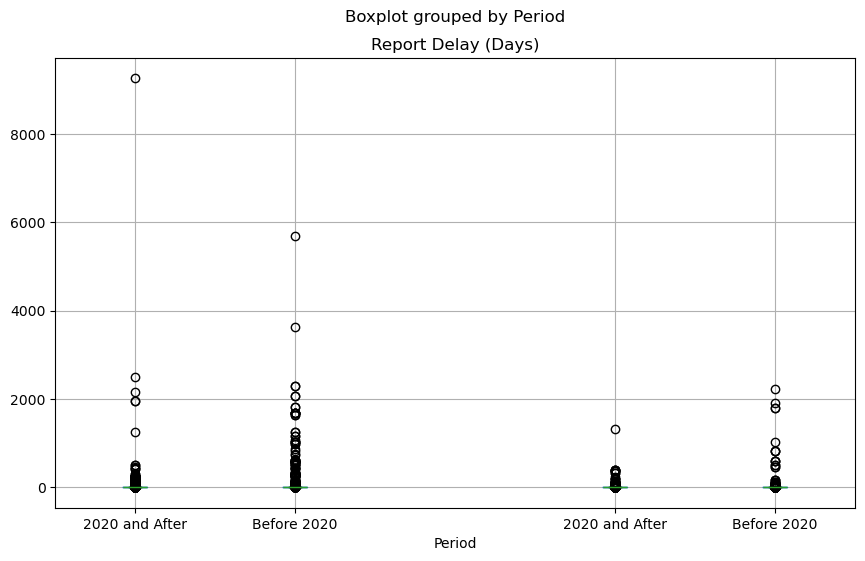

In [16]:
# t-test for the difference in response time before and after 2020 for historical spills
historical_before_2020 = historical_spills[historical_spills['Period'] == 'Before 2020']['Report Delay (Days)']
historical_after_2020 = historical_spills[historical_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(historical_before_2020, historical_after_2020, equal_var=False)
print(f'\nHistorical Spills T-Statistic: {t_stat:.4f}')
print(f'Historical Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for historical spills
if p_value < 0.05:
    print('The difference in response time for historical spills is statistically significant.')
else:
    print('The difference in response time for historical spills is not statistically significant.')
    
# t-test for the difference in response time before and after 2020 for recent spills
recent_before_2020 = recent_spills[recent_spills['Period'] == 'Before 2020']['Report Delay (Days)']
recent_after_2020 = recent_spills[recent_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(recent_before_2020, recent_after_2020, equal_var=False)
print(f'\nRecent Spills T-Statistic: {t_stat:.4f}')
print(f'Recent Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for recent spills
if p_value < 0.05:
    print('The difference in response time for recent spills is statistically significant.')
else:
    print('The difference in response time for recent spills is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2020 for historical and recent spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for historical spills
historical_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[1, 2])

# Plot the response time distribution for recent spills
recent_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[4, 5])

# Save the plot to the /output directory
plt.savefig('analysis/output/response_time_distribution.png')


In [ ]:
# Historical only
historical_spills = historical_spills.copy()
historical_spills['Post2020'] = historical_spills['Period'].apply(lambda x: 1 if x == '2020 and After' else 0)
model_hist = smf.ols('Q("Report Delay (Days)") ~ Post2020', data=historical_spills).fit()
print("Historical Spills:\n", model_hist.summary())

# Recent only
recent_spills = recent_spills.copy()
recent_spills['Post2020'] = recent_spills['Period'].apply(lambda x: 1 if x == '2020 and After' else 0)
model_recent = smf.ols('Q("Report Delay (Days)") ~ Post2020', data=recent_spills).fit()
print("\nRecent Spills:\n", model_recent.summary())



Historical Spills:
                                OLS Regression Results                               
Dep. Variable:     Q("Report Delay (Days)")   R-squared:                       0.002
Model:                                  OLS   Adj. R-squared:                  0.001
Method:                       Least Squares   F-statistic:                     8.265
Date:                      Mon, 31 Mar 2025   Prob (F-statistic):            0.00406
Time:                              13:58:43   Log-Likelihood:                -35825.
No. Observations:                      5312   AIC:                         7.165e+04
Df Residuals:                          5310   BIC:                         7.167e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [ ]:
# Label both groups, combine
historical_spills['Group'] = 'Historical'
recent_spills['Group'] = 'Recent'
combined = pd.concat([historical_spills, recent_spills], ignore_index=True)

combined['Post2020'] = combined['Period'].apply(lambda x: 1 if x == '2020 and After' else 0)

# Run regression with interactions by group
model = smf.ols('Q("Report Delay (Days)") ~ Post2020 * Group', data=combined).fit()
print(model.summary())


                               OLS Regression Results                               
Dep. Variable:     Q("Report Delay (Days)")   R-squared:                       0.006
Model:                                  OLS   Adj. R-squared:                  0.006
Method:                       Least Squares   F-statistic:                     31.12
Date:                      Mon, 31 Mar 2025   Prob (F-statistic):           4.78e-20
Time:                              13:53:41   Log-Likelihood:                -99827.
No. Observations:                     15990   AIC:                         1.997e+05
Df Residuals:                         15986   BIC:                         1.997e+05
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

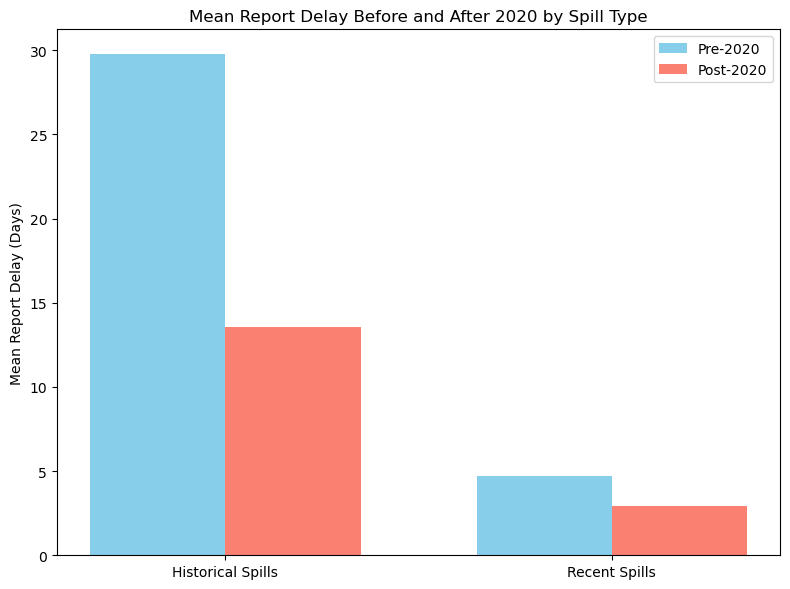

In [20]:
import matplotlib.pyplot as plt

# Data
pre_means = [29.75, 4.71]
post_means = [29.75 - 16.21, 4.71 - 1.79]
labels = ['Historical Spills', 'Recent Spills']

x = range(len(labels))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar([i - width / 2 for i in x], pre_means, width, label='Pre-2020', color='skyblue')
ax.bar([i + width / 2 for i in x], post_means, width, label='Post-2020', color='salmon')

# Labels and aesthetics
ax.set_ylabel('Mean Report Delay (Days)')
ax.set_title('Mean Report Delay Before and After 2020 by Spill Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Save and show
plt.tight_layout()
plt.savefig('report_delay_barplot.png')
plt.show()


| Group             | Pre-2020 Mean | Post-2020 Change (coef) | p-value | Significant (p < 0.05) |
|------------------|---------------|--------------------------|---------|-------------------------|
| Historical Spills| 29.75         | -16.21                   | 0.004   | Yes                     |
| Recent Spills    | 4.71          | -1.79                    | 0.053   | No                      |


### Analysis of Reporting Delays for Historical and Recent Spills
We analyzed reporting delays for historical and recent spills before and after 2020 using simple OLS regressions. For historical spills, the average delay decreased significantly by approximately 16.2 days after 2020 (p = 0.004), dropping from a pre-2020 mean of 29.75 days. In contrast, the reduction for recent spills was smaller—about 1.8 days—and only marginally significant (p = 0.053), starting from a much lower pre-2020 average of 4.71 days. These results suggest that the most substantial improvements in timeliness occurred within the historical spill reporting process.

## Differences in Reporting Delays by Spill Type

In [22]:
import pandas as pd
import statsmodels.formula.api as smf

# Combine the datasets and label the groups
historical_spills['SpillType'] = 0  # historical = 0
recent_spills['SpillType'] = 1      # recent = 1

combined = pd.concat([historical_spills, recent_spills], ignore_index=True)

# Convert 'Period' to binary: 0 = Before 2020, 1 = 2020 and After
combined['Post2020'] = combined['Period'].apply(lambda x: 1 if x == '2020 and After' else 0)

# Interaction term is created implicitly in the regression
model = smf.ols('Q("Report Delay (Days)") ~ Post2020 + SpillType + Post2020:SpillType', data=combined).fit()

print(model.summary())


                               OLS Regression Results                               
Dep. Variable:     Q("Report Delay (Days)")   R-squared:                       0.006
Model:                                  OLS   Adj. R-squared:                  0.006
Method:                       Least Squares   F-statistic:                     31.12
Date:                      Mon, 31 Mar 2025   Prob (F-statistic):           4.78e-20
Time:                              14:02:43   Log-Likelihood:                -99827.
No. Observations:                     15990   AIC:                         1.997e+05
Df Residuals:                         15986   BIC:                         1.997e+05
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

| Term                          | Coefficient | Std. Error | p-value | Interpretation                                                                 |
|-------------------------------|-------------|------------|---------|---------------------------------------------------------------------------------|
| Intercept                     | 29.75       | 2.44       | <0.001  | Historical spills, pre-2020 average report delay                               |
| Post2020                      | -16.21      | 3.42       | <0.001  | Historical spills saw a 16.2-day reduction in delay after 2020                 |
| Group: Recent Spills          | -25.03      | 2.91       | <0.001  | Recent spills had a 25-day shorter delay than historical spills pre-2020       |
| Post2020 × Recent Spills      | +14.43      | 4.20       | 0.001   | Recent spills improved **14.4 days less** than historical spills post-2020     |


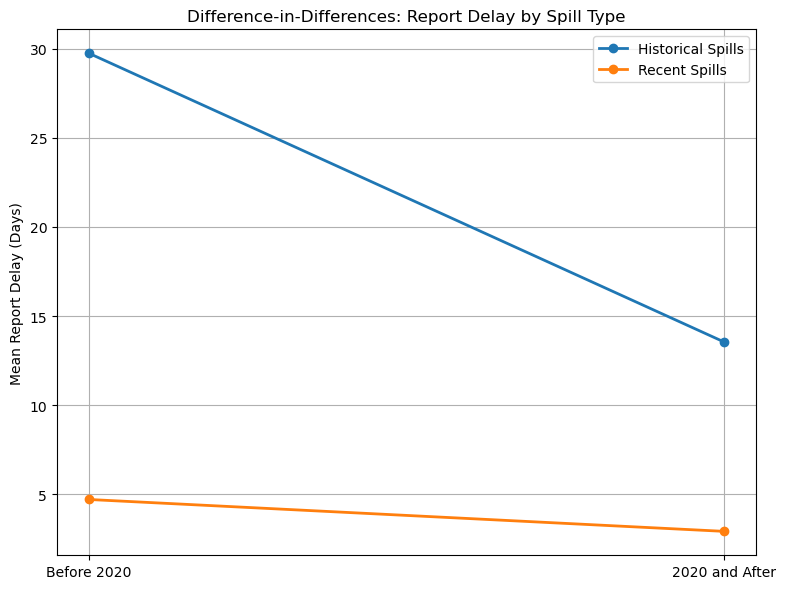

In [24]:
import matplotlib.pyplot as plt

# X-axis positions: 0 = Before 2020, 1 = 2020 and After
x = [0, 1]

# Y-values for each group
historical = [29.75, 29.75 - 16.21]  # Before and after for historical
recent = [4.71, 4.71 - 1.79]         # Before and after for recent

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, historical, marker='o', label='Historical Spills', linewidth=2)
ax.plot(x, recent, marker='o', label='Recent Spills', linewidth=2)

# Aesthetics
ax.set_xticks(x)
ax.set_xticklabels(['Before 2020', '2020 and After'])
ax.set_ylabel('Mean Report Delay (Days)')
ax.set_title('Difference-in-Differences: Report Delay by Spill Type')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


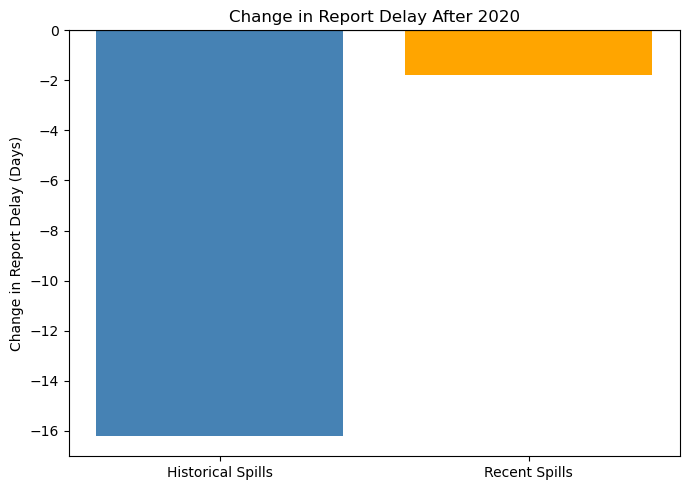

In [25]:
import matplotlib.pyplot as plt

improvements = [-16.21, -1.79]
labels = ['Historical Spills', 'Recent Spills']

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, improvements, color=['steelblue', 'orange'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Change in Report Delay (Days)')
ax.set_title('Change in Report Delay After 2020')
plt.tight_layout()
plt.show()


**Interpretation of Difference-in-Differences Model**

This Difference-in-Differences model estimates how report delays changed after 2020 for two groups—historical and recent spills—and compares the *magnitude of change* between them. The pre-2020 average delay for historical spills was approximately 29.75 days. After 2020, historical spills saw a statistically significant reduction of about 16.2 days (p < 0.001).

Recent spills, by contrast, already had much shorter average delays (about 25 days less than historical spills before 2020). The DiD interaction term (+14.4 days, p = 0.001) shows that the improvement in timeliness for recent spills was significantly smaller than that for historical spills. In other words, while both groups saw reductions in report delays after 2020, the gains were **substantially greater** for historical spills.

This suggests that any policy or process changes implemented around 2020 had a **disproportionately stronger effect** on addressing delays in the historical spill category.